In [2]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation as animation

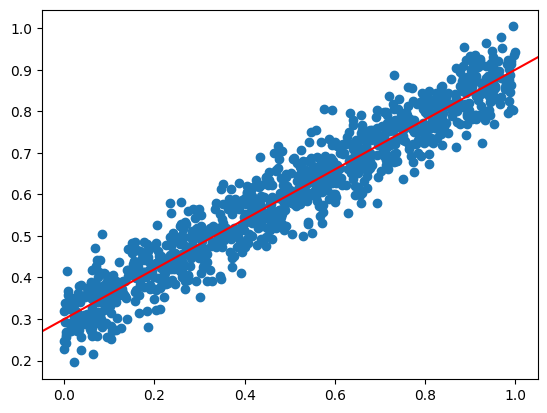

In [3]:
X = np.random.uniform(size=(1000,))
y = 0.3 + 0.6 * X + np.random.randn(1000,) * 0.05

plt.scatter(X, y)
plt.axline((0, 0.3), (1.0, 0.3 + 0.6), color='r')

0.4967141530112327 -0.13826430117118466


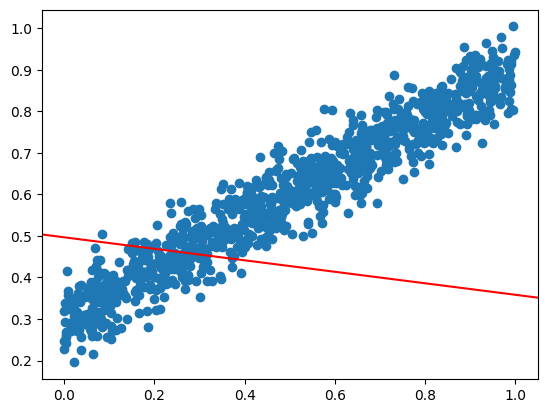

0.3071317908737205 0.5882994821303767


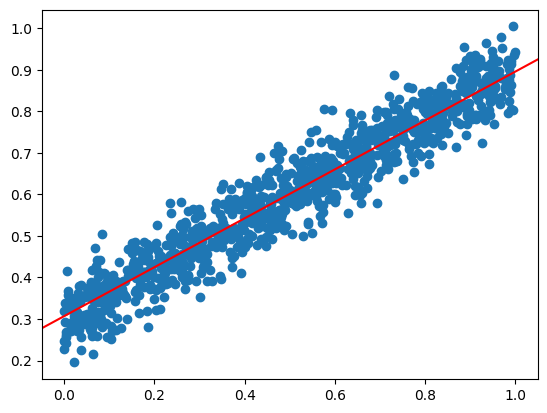

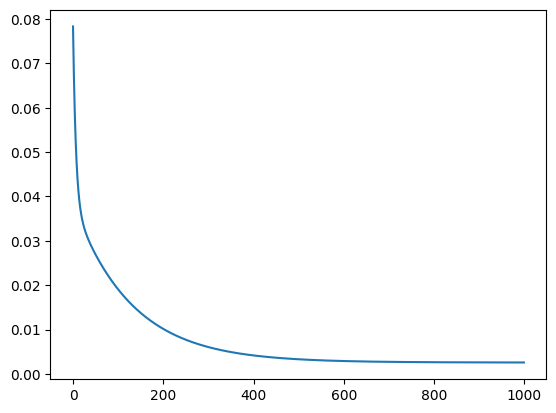

In [4]:
np.random.seed(42)
b = np.random.randn(1).item()
w = np.random.randn(1).item()
print(b, w)
plt.scatter(X, y)
plt.axline((0, b), (1.0, b + w), color='r')
plt.show()

lr = 0.03

params_over_time = []
loss_over_time = []

for i in range(1000):
    y_pred = b + w*X
    error = y - y_pred
    MSE = (error ** 2).mean()

    b_grad = -2 * error.mean()
    w_grad = -2 * (X*error).mean()

    b -= lr * b_grad
    w -= lr * w_grad

    if i % 10 == 0:
        params_over_time.append((b, w))

    loss_over_time.append(MSE)

print(b, w)
plt.scatter(X, y)
plt.axline((0, b), (1.0, b + w), color='r')
plt.show()

plt.plot(np.arange(len(loss_over_time)), loss_over_time)


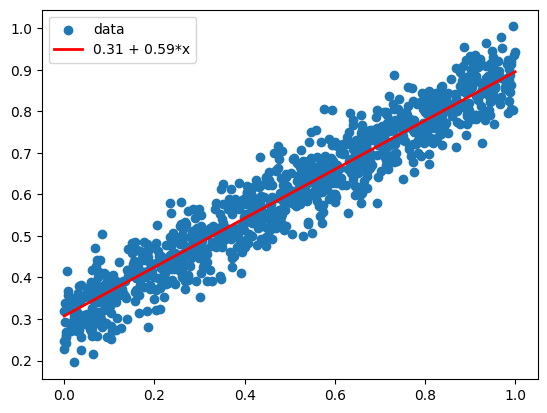

In [28]:
fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)

scat = ax.scatter(X, y, label=f'data')
line = ax.plot([0, 1], [b, b + w], color='r', label=f'{b:.2f} + {w:.2f}*x', linewidth=2)[0]
ax.legend()

def update(frame):
    b, w = params_over_time[frame]
    line.set_ydata([b, b + w])
    line.set_label(f'{b:.2f} + {w:.2f}*x')
    return (scat, line)

ani = animation.FuncAnimation(fig=fig, func=update, frames=len(params_over_time), interval=30)
ani.save("anim1.gif")
plt.show()

In [30]:
import torch.nn as nn
import torch

class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        x = self.linear(x)
        return x


In [32]:
model = LinearRegression()
print("Model before training\n", model.state_dict())

loss_fn = nn.MSELoss()
X_tensor = torch.Tensor(X).reshape(-1, 1)
y_tensor = torch.Tensor(y).reshape(-1, 1)

optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

loss_over_time = []

model.train()
for epoch in range(1000):
    optimizer.zero_grad()

    y_pred = model(X_tensor)

    loss = loss_fn(y_pred, y_tensor)
    loss.backward()

    optimizer.step()

    loss_over_time.append(loss.item())

model.eval()

print("Model after training\n", model.state_dict())


Model before training
 OrderedDict([('linear.weight', tensor([[0.8958]])), ('linear.bias', tensor([-0.9825]))])
Model after training
 OrderedDict([('linear.weight', tensor([[0.6174]])), ('linear.bias', tensor([0.2915]))])


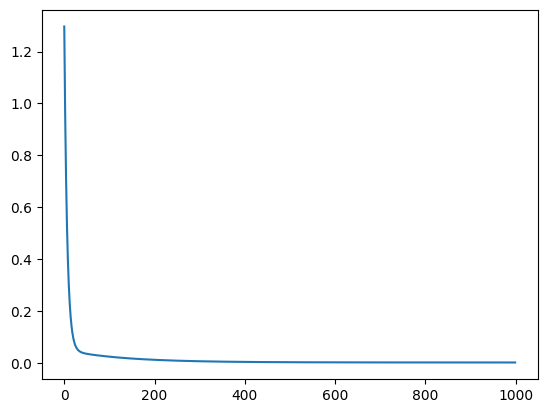

In [33]:
plt.plot(np.arange(len(loss_over_time)), loss_over_time)

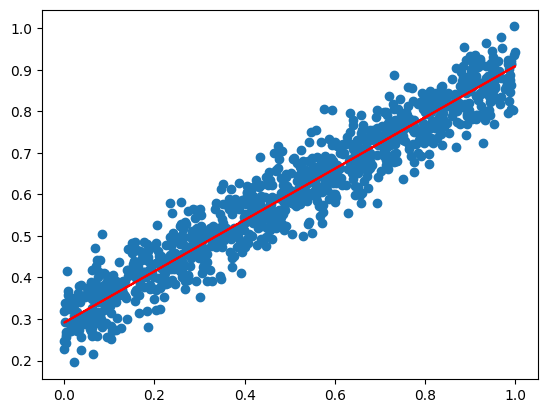

In [40]:
plt.scatter(X, y)
plt.plot(X, model(X_tensor).detach().numpy(), c="r")